In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_moons, make_s_curve

from Autoencoders import ConformalAutoencoder
from helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler
from data import make_half_sphere
from metrics import evaluate_conformality

random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
    
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    
    def forward(self, z):
        return self.fc(z)

In [3]:
data, labels = make_half_sphere(n_samples=3000, noise=0.05, random_state=random_state)
data = torch.tensor(data, dtype=torch.float32).to(device)
val_data, val_labels = make_half_sphere(n_samples=1000, noise=0.05, random_state=random_state+1)
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)

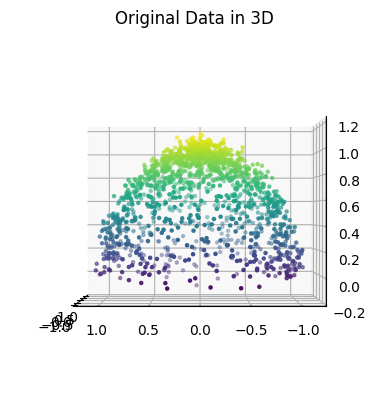

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0].cpu(), data[:, 1].cpu(), data[:, 2].cpu(), c=labels, s=5)
ax.set_title("Original Data in 3D")
ax.view_init(0, 180, 0)
plt.show()

In [5]:
# define model parameters
latent_dim = 2
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 128

train_dataloader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)


dir_path = "models/conformal_autoencoder_cosine_comp_halfsphere"

In [6]:
lambda_isos = np.logspace(-3, 2, 9)
lambda_isos = np.concat([np.zeros(1), lambda_isos])

In [7]:
from metrics import conformality_cosine2_loss

In [8]:
import os

def modelpath(dir_path, lambda_iso, index):
    os.makedirs(dir_path, exist_ok=True)
    return f"{dir_path}/lambda_{lambda_iso:.3f}_model_{index+1}.pth"

In [9]:
num_epochs = 1000
# train same model multiple times to average results
num_models = 4

recon_errors = []
regularization_errors = []


for i, lambda_iso in enumerate(lambda_isos):
    recon_error = 0
    regularization = 0
    for j in range(num_models):
        print(f"Training model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f}")
        
        encoder = Encoder(input_dim, latent_dim).to(device)
        decoder = Decoder(latent_dim, output_dim).to(device)
        model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_iso).to(device)
        model.conformality_loss = conformality_cosine2_loss

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

        # Train the model
        model.train_model(train_dataloader, val_dataloader, batch_size=batch_size, epochs=num_epochs,
                          optimizer=optimizer, scheduler=scheduler, verbose=True)

        # Save the model and optimizer state
        model_path = modelpath(dir_path, lambda_iso, j)
        torch.save(model.state_dict(), model_path)
        print(f"Model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f} trained and saved.")

        # evaluation
        model.eval()
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)
        
        recon_error += nn.MSELoss()(reconstruction, val_data).item()

        regularization += model.conformality_loss(model.decoder, encoded_data).item()
    
    recon_errors.append(recon_error/ num_models)
    regularization_errors.append(regularization/num_models)
    

Training model 1/4 with lambda_iso=0.000


/home/maxheise/anaconda3/envs/ML/lib/python3.13/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [100/1000], Loss: 0.00093503, Reconstruction Loss: 0.00093503, Conformal Loss: 0.01876515
Epoch [100/1000], Validation Loss: 0.00109934, Reconstruction Loss: 0.00109934, Conformal Loss: 0.01559171
Epoch [200/1000], Loss: 0.00083459, Reconstruction Loss: 0.00083459, Conformal Loss: 0.01729126
Epoch [200/1000], Validation Loss: 0.00107232, Reconstruction Loss: 0.00107232, Conformal Loss: 0.01752126
Epoch [300/1000], Loss: 0.00082893, Reconstruction Loss: 0.00082893, Conformal Loss: 0.01740009
Epoch [300/1000], Validation Loss: 0.00101503, Reconstruction Loss: 0.00101503, Conformal Loss: 0.02011504
Epoch [400/1000], Loss: 0.00080459, Reconstruction Loss: 0.00080459, Conformal Loss: 0.01841820
Epoch [400/1000], Validation Loss: 0.00101895, Reconstruction Loss: 0.00101895, Conformal Loss: 0.01951127
Epoch [500/1000], Loss: 0.00078824, Reconstruction Loss: 0.00078824, Conformal Loss: 0.01949871
Epoch [500/1000], Validation Loss: 0.00100413, Reconstruction Loss: 0.00100413, Conformal Lo

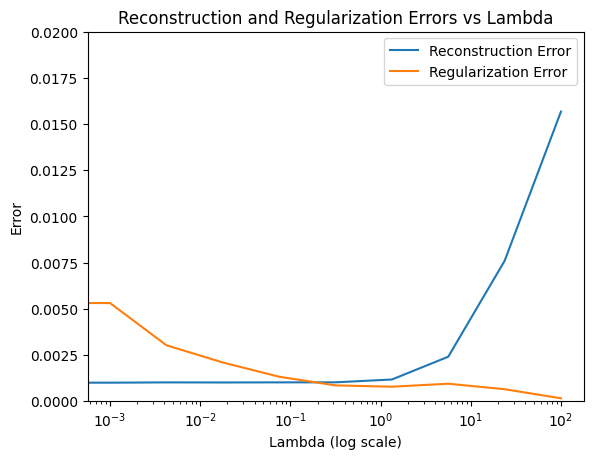

In [19]:
plt.plot(lambda_isos, recon_errors, label='Reconstruction Error')
plt.plot(lambda_isos, regularization_errors, label='Regularization Error')
plt.ylim(0, 0.02)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Error')
plt.title('Reconstruction and Regularization Errors vs Lambda')
plt.legend()
plt.show()

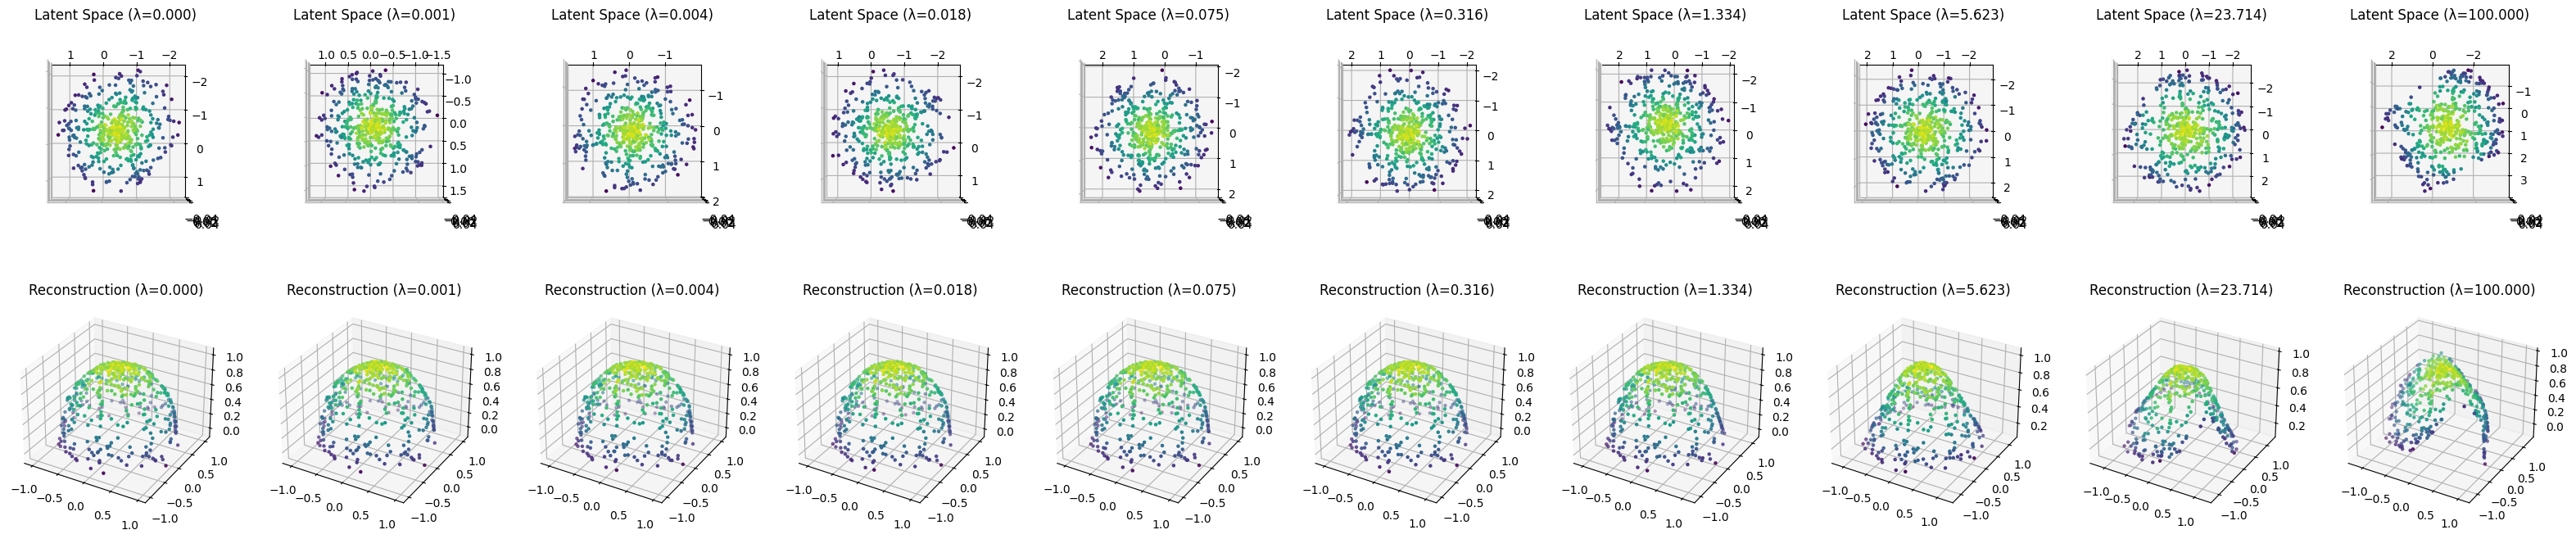

In [20]:
# plot samples and latent space at different lambdas
fig, axs = plt.subplots(2, 10, figsize=(40, 8), subplot_kw=dict(projection='3d'))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 2)
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    axs[0, i].scatter(encoded_data[:, 0].cpu(), encoded_data[:, 1].cpu(), c=val_labels, s=5)
    axs[0, i].set_title(f'Latent Space (λ={lambda_iso:.3f})')
    axs[0, i].view_init(90, 90, 0)
    # axs[0, i].set_xticks([])
    # axs[0, i].set_yticks([])
    #plot 3d data
    axs[1, i].scatter(reconstruction[:, 0].cpu(), reconstruction[:, 1].cpu(), reconstruction[:, 2].cpu(), c=val_labels, s=5)
    axs[1, i].set_title(f'Reconstruction (λ={lambda_iso:.3f})')

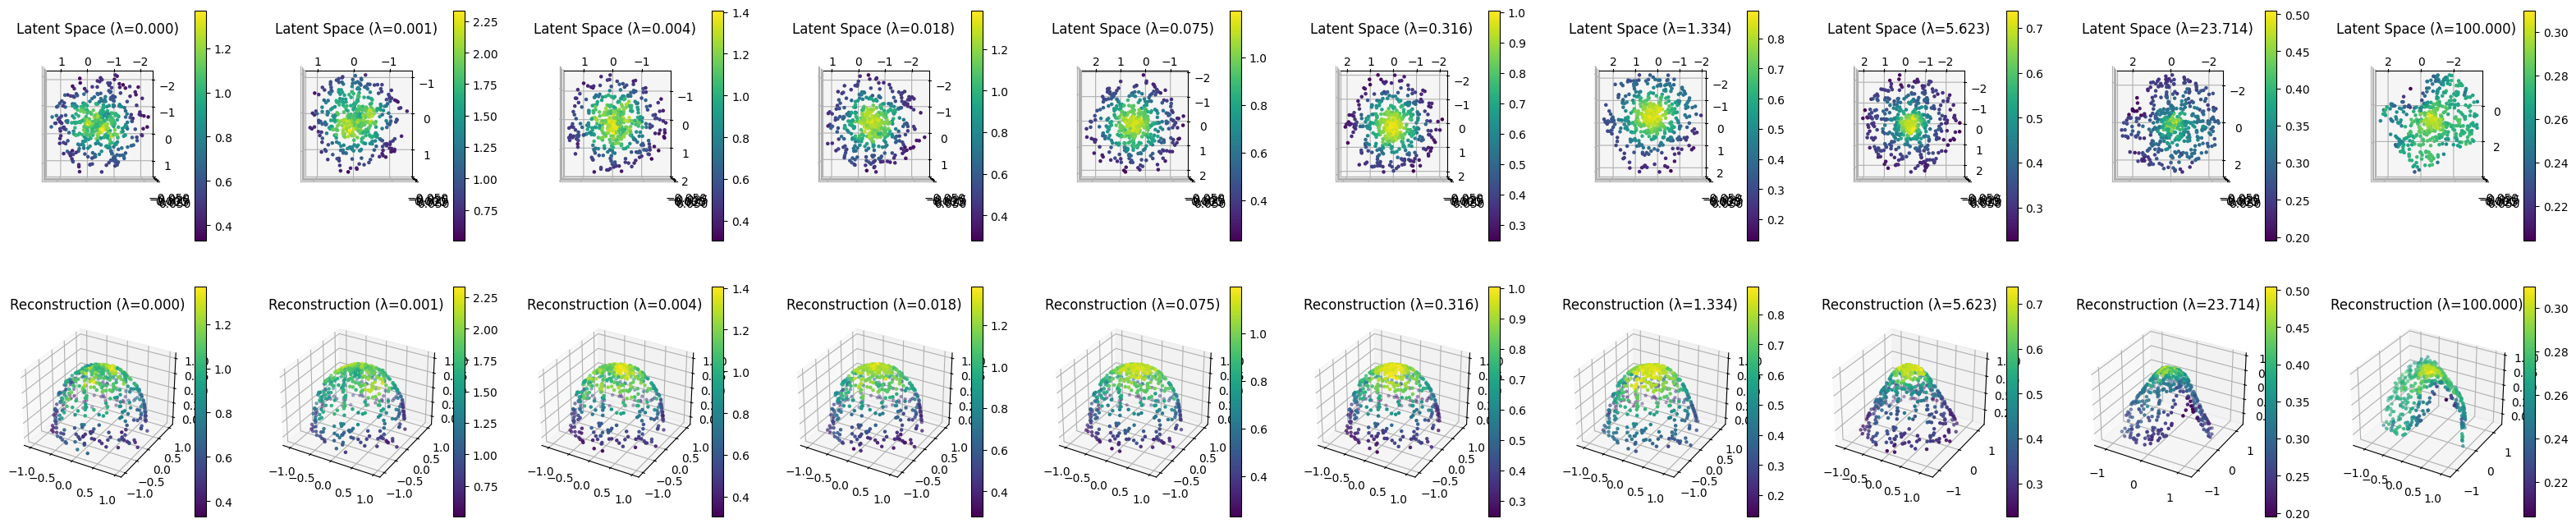

In [12]:
fig, axs = plt.subplots(2, 10, figsize=(40, 8), subplot_kw=dict(projection='3d'))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 2)
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    trace_vals = np.zeros_like(encoded_data[:, 0].cpu())
    for j, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = model.decode(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(model.decode, z)[0,:,0,:]

        # Compute the trace of J^T J
        JtJ = J.T @ J
        trace_JtJ = torch.trace(JtJ)

        # Store the trace value as a label for the point
        trace_vals[j] = trace_JtJ.item() / JtJ.shape[0]  # Normalize by the number of dimensions

    p = axs[0, i].scatter(encoded_data[:, 0].cpu(), encoded_data[:, 1].cpu(), c=trace_vals, s=5)
    plt.colorbar(p)
    axs[0, i].set_title(f'Latent Space (λ={lambda_iso:.3f})')
    axs[0, i].view_init(90, 90, 0)
    # axs[0, i].set_xticks([])
    # axs[0, i].set_yticks([])
    #plot 3d data
    p = axs[1, i].scatter(reconstruction[:, 0].cpu(), reconstruction[:, 1].cpu(), reconstruction[:, 2].cpu(), c=trace_vals, s=5)
    plt.colorbar(p)
    axs[1, i].set_title(f'Reconstruction (λ={lambda_iso:.3f})')

In [13]:
statses = []
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 2)
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    statses.append(evaluate_conformality(model, data))

df = pd.DataFrame(statses, index=lambda_isos)
# styled_df = df.style.highlight_min(color='green').highlight_max(color='coral')

In [14]:
styled_df = df.style \
    .background_gradient(subset=[
            'reconstruction_error',
            'diagonal_gini',
            'lambda_std',
            'lambda_std_normed',
            'off_diag_mean',
            'off_diag_norm',
            'off_diag_mean_normed',
            'off_diag_norm_normed',
            'jTj_minus_lambdaI_mean',
            'jTj_minus_lambdaI_norm',
            'jTj_minus_lambdaI_mean_normed',
            'jTj_minus_lambdaI_norm_normed',
            'determinant_vs_estimate_std',
            ], cmap='Reds') \
    .background_gradient(subset=[
        'determinant_vs_estimate_mean'
    ], cmap='Greens')\
    .background_gradient(subset=[
        'lambda_mean',
        'latent_std',
        'latent_std_max',
        'latent_std_min',
        'latent_norm',
    ], cmap='Blues')

styled_df

,reconstruction_error,diagonal_gini,lambda_mean,lambda_std,lambda_std_normed,off_diag_mean,off_diag_norm,off_diag_mean_normed,off_diag_norm_normed,jTj_minus_lambdaI_mean,jTj_minus_lambdaI_norm,jTj_minus_lambdaI_mean_normed,jTj_minus_lambdaI_norm_normed,determinant_vs_estimate_mean,determinant_vs_estimate_std,latent_std,latent_std_max,latent_std_min,latent_norm
0.000000,0.000781,0.088952,0.874684,0.255423,0.292018,0.039118,0.110642,0.048083,0.135999,0.073564,0.164119,0.092559,0.206625,0.984499,0.022672,0.652426,0.653106,0.651746,41.569313
0.001000,0.000786,0.086959,1.560483,0.440723,0.282428,0.061654,0.174384,0.040437,0.114373,0.124322,0.275232,0.083917,0.185860,0.988421,0.013825,0.485706,0.495909,0.475503,27.659119
0.004217,0.000778,0.059251,0.957617,0.311443,0.325227,0.028590,0.080866,0.031776,0.089876,0.054583,0.120803,0.061402,0.136388,0.993679,0.007781,0.624861,0.635727,0.613995,34.753895
0.017783,0.000787,0.046751,0.918239,0.315545,0.343641,0.020803,0.058840,0.025782,0.072921,0.039467,0.088133,0.049157,0.109566,0.995433,0.007086,0.645081,0.645918,0.644244,43.356983
0.074989,0.000788,0.036279,0.800095,0.271442,0.339262,0.012724,0.035990,0.018613,0.052645,0.025708,0.057155,0.036752,0.081977,0.997452,0.003908,0.689130,0.691268,0.686992,41.335678
0.316228,0.000825,0.032740,0.691547,0.233247,0.337282,0.008425,0.023829,0.014218,0.040215,0.017909,0.039569,0.030588,0.067716,0.998177,0.002888,0.739619,0.747954,0.731284,40.542217
1.333521,0.000932,0.029394,0.603624,0.205472,0.340397,0.008224,0.023261,0.015619,0.044178,0.015910,0.035355,0.030316,0.067377,0.998302,0.002523,0.790669,0.797119,0.784220,44.904087
5.623413,0.002302,0.035912,0.467589,0.152330,0.325776,0.007077,0.020016,0.016768,0.047427,0.014684,0.032478,0.034724,0.076741,0.997822,0.003219,0.878012,0.880385,0.875639,48.800289
23.713737,0.006008,0.037838,0.328690,0.070187,0.213536,0.005932,0.016778,0.018264,0.051658,0.011956,0.026614,0.037183,0.082603,0.997698,0.002694,1.011845,1.041217,0.982473,55.344906
100.000000,0.010319,0.011961,0.274110,0.018319,0.066830,0.001918,0.005425,0.007177,0.020300,0.003527,0.007873,0.013158,0.029374,0.999638,0.000904,1.101000,1.157081,1.044918,75.322212
